# 

In [41]:
import glob
import numpy as np
from matplotlib import pyplot as plt
import yaml
import os
from src.evaluation import plotting
from plotting_rules import colours, pretty_names
from src.training.best_checkpoint import checkpoint_scores

In [43]:
n_projections = 100
paths = glob.glob(f"/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/*/checkpoints/*_slicedHLwas{n_projections}.npz")
print(f"Found {len(paths)} distances")
log_dirs = []
tags = []
distances = []
errors = []
val_loss = []
was_tag = f"_slicedHLwas{n_projections}.npz"
for path in paths:
    log_dir = os.path.dirname(os.path.dirname(path))
    checkpoints = checkpoint_scores(log_dir)
    assert was_tag in path
    model_name = path.replace(was_tag, ".pt")
    for ckpt in checkpoints:
        if ckpt['path'] == model_name:
            val_loss.append(ckpt['value'])
            break
    else:
        val_loss.append(None)
        print(f"Didn't find {model_name}")
        
    log_dirs.append(log_dir)
    tag = os.path.basename(glob.glob(os.path.join(log_dir, "_a_*"))[0])[3:].replace("_", " ")
    print(tag)
    tags.append(tag)
    
    with open(path, 'r') as f:
        try:
            result = yaml.safe_load(f)
        except Exception:
            result = {"distance": None, "error": None}
    distances.append(result["distance"])
    errors.append(result["error"])

Found 3 distances
padded photons v2
distill of padded photons v1
distilled 2 from padded photons v1


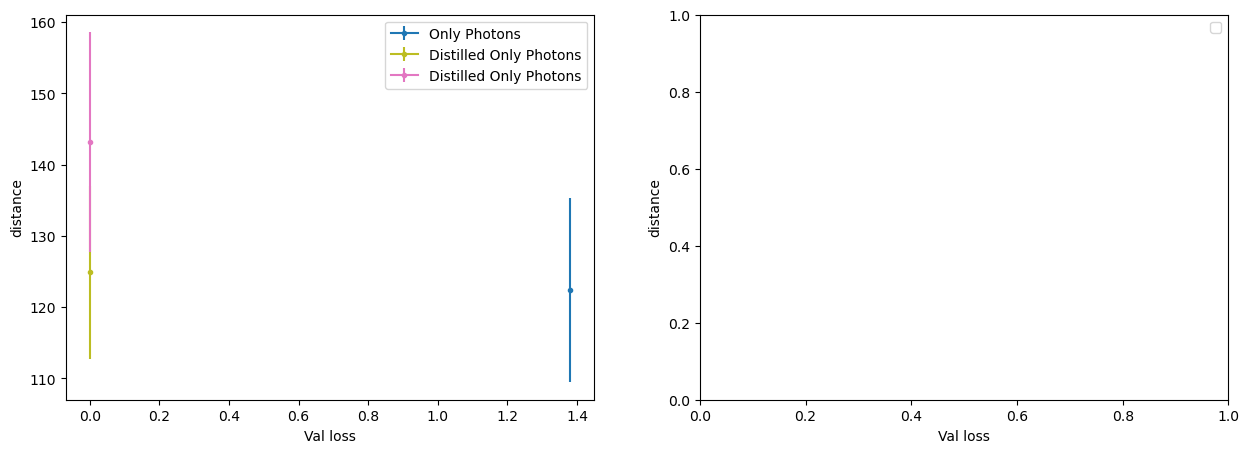

In [44]:
fig, axarr = plt.subplots(1, 2, figsize=(15, 5))

order = np.argsort(distances)
for i in order:
    tag = tags[i]
    c = colours[tag]
    pretty = pretty_names[tag]
    if "Photons" in pretty:
        ax = axarr[0]
    else:
        ax = axarr[1]
    
    ax.errorbar([val_loss[i]], [distances[i]], [errors[i]], c=c, marker='.', label=pretty_names[tag])
for ax in axarr:
    ax.legend()
    ax.set_xlabel("Val loss")
    ax.set_ylabel("distance")

In [29]:
plt.errorbar?

Signature:
plt.errorbar(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    yerr: 'float | ArrayLike | None' = None,
    xerr: 'float | ArrayLike | None' = None,
    fmt: 'str' = '',
    *,
    ecolor: 'ColorType | None' = None,
    elinewidth: 'float | None' = None,
    capsize: 'float | None' = None,
    barsabove: 'bool' = False,
    lolims: 'bool | ArrayLike' = False,
    uplims: 'bool | ArrayLike' = False,
    xlolims: 'bool | ArrayLike' = False,
    xuplims: 'bool | ArrayLike' = False,
    errorevery: 'int | tuple[int, int]' = 1,
    capthick: 'float | None' = None,
    data=None,
    **kwargs,
) -> 'ErrorbarContainer'
Docstring:
Plot y versus x as lines and/or markers with attached errorbars.

*x*, *y* define the data locations, *xerr*, *yerr* define the errorbar
sizes. By default, this draws the data markers/lines as well as the
errorbars. Use fmt='none' to draw errorbars without any data markers.

.. versionadded:: 3.7
   Caps and error lines are drawn in polar coordi